In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/lakshmistm/q2-customers-csv/q2_customers.csv')

# Display basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (500, 6)

Data Types:
 age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


## Task 1 — Data Preparation

The dataset contains 500 customer records with 6 numerical features and no missing values.

Scaling is essential before applying K-Means because K-Means calculates distances
between data points. If features have very different ranges — for example,
annual_spend ranges in thousands while visits_per_month is a small number —
the algorithm will be dominated by the larger-valued features. This means
annual_spend would have a much greater influence on cluster assignments than
visits_per_month, even if visits_per_month is equally important. StandardScaler
ensures all features contribute equally by transforming each to have a mean of
0 and a standard deviation of 1.

In [3]:
# Scale all features using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Scaling complete!")
print("Scaled data shape:", df_scaled.shape)

Scaling complete!
Scaled data shape: (500, 6)


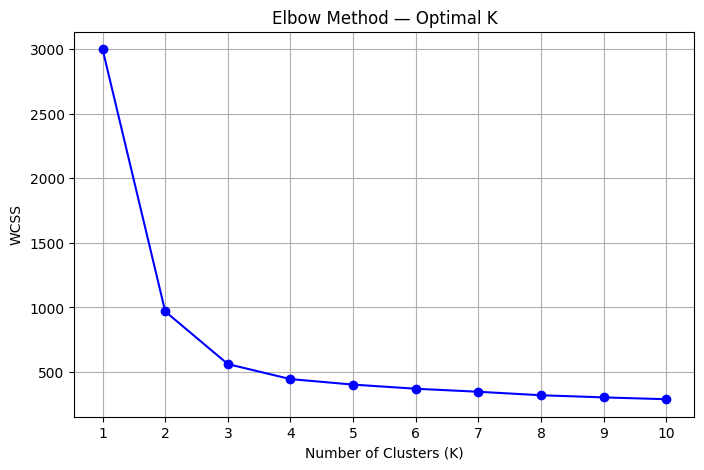

In [4]:
# Compute WCSS for K = 1 through 10
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='blue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Task 2 — Choosing K (Elbow Method)

The WCSS plot shows a sharp decline from K=1 to K=3, after which the curve
begins to flatten. The elbow point occurs at K=4, where adding more clusters
produces only marginal reductions in WCSS. Therefore, K=4 is selected as the
optimal number of clusters as it provides a good balance between minimising
within-cluster variance and keeping the model simple and interpretable.

In [5]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add cluster column to dataframe
df['cluster'] = kmeans.labels_

# Print cluster centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                         columns=df.columns[:-1])
centroids.index.name = 'Cluster'
print("Cluster Centroids:")
print(centroids.round(2))

# Cluster size
print("\nCluster Sizes:")
print(df['cluster'].value_counts().sort_index())

Cluster Centroids:
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  

Cluster Sizes:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


## Task 3 — K-Means Clustering Interpretation

**Cluster 0 — Young Frequent Low-Spenders (170 customers)**
Average age 25, low annual spend of around 14,847, highest visit frequency of around 14
visits per month, small basket size, and very recent last visit of around 9 days.
These are young, regular shoppers who visit often but spend little each time.

**Cluster 1 — High-Value Lapsed Customers (80 customers)**
Average age 57, very high annual spend of around 89,814, very low visit frequency
of around 2 visits per month, large basket size, but last visited around 148 days ago.
These are valuable customers who have become inactive and need re-engagement.

**Cluster 2 — Mid-Value Regular Customers (165 customers)**
Average age 40, moderate annual spend of around 43,340, moderate visit frequency
of around 8 visits per month, medium basket size, last visited around 35 days ago.
These are stable, consistent customers with balanced shopping behaviour.

**Cluster 3 — High-Value Occasional Shoppers (85 customers)**
Average age 57, very high annual spend of around 89,036, low visit frequency of
around 3 visits per month, largest basket size of around 5,751, last visited around 65 days ago.
These customers visit rarely but spend heavily each time they shop.

In [6]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)

# Print explained variance ratio
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nTotal Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Print feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("\nFeature Loadings:")
print(loadings.round(4))

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)

Total Variance Explained: 89.13%

Feature Loadings:
        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


## Task 4 — PCA Interpretation

**Explained Variance Ratio:**
PC1 explains 83.56% of the total variance and PC2 explains 5.57%, giving a
combined total of 89.13%. This means that just 2 components capture almost
90% of the information in the original 6 features, making PCA an effective
dimensionality reduction technique for this dataset.

**PC1 Interpretation:**
PC1 has high positive loadings on age (0.4116), annual_spend (0.4215),
basket_size (0.4120), num_categories_purchased (0.4140), and
days_since_last_visit (0.3786), and a high negative loading on
visits_per_month (-0.4104). This means PC1 separates older, high-spending,
infrequent shoppers from younger, low-spending, frequent visitors.
PC1 can be interpreted as an overall customer value and engagement axis.

**PC2 Interpretation:**
PC2 is strongly driven by days_since_last_visit (0.9112), with smaller
contributions from other features. This means PC2 primarily captures
how recently a customer has visited, separating recently active customers
from lapsed ones regardless of their spending level.

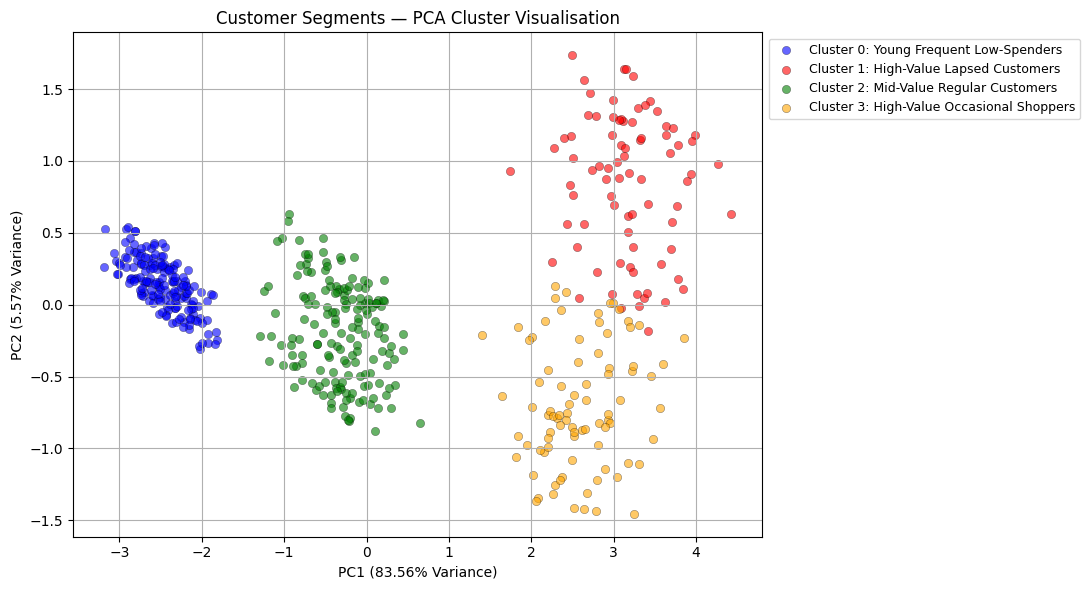

In [7]:
# Scatter plot of PC1 vs PC2 coloured by cluster label
plt.figure(figsize=(11, 6))

colors = ['blue', 'red', 'green', 'orange']
cluster_names = [
    'Cluster 0: Young Frequent Low-Spenders',
    'Cluster 1: High-Value Lapsed Customers',
    'Cluster 2: Mid-Value Regular Customers',
    'Cluster 3: High-Value Occasional Shoppers'
]

for i in range(4):
    mask = df['cluster'] == i
    plt.scatter(
        df_pca[mask, 0],
        df_pca[mask, 1],
        c=colors[i],
        label=cluster_names[i],
        alpha=0.6,
        edgecolors='k',
        linewidths=0.3
    )

plt.title('Customer Segments — PCA Cluster Visualisation')
plt.xlabel('PC1 (83.56% Variance)')
plt.ylabel('PC2 (5.57% Variance)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()